In [1]:
import os
import sys
import pandas as pd

# Navigate up one directory to the project root and add it to sys.path
sys.path.append(os.path.abspath(os.path.join('..')))

# Now you can cleanly import your configurations!
from src.config import RAW_TRAIN_DATA_PATH, RAW_TEST_DATA_PATH

In [2]:
train = pd.read_csv(RAW_TRAIN_DATA_PATH)
test = pd.read_csv(RAW_TEST_DATA_PATH)

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='SalePrice', ylabel='Count'>

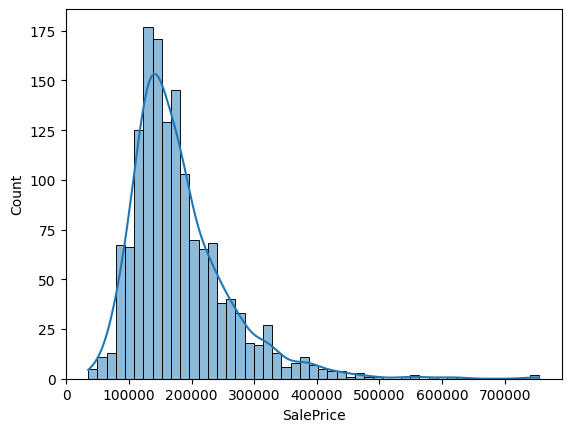

In [5]:
sns.histplot(train.SalePrice, kde=True)

In [6]:
log_target = np.log1p(train['SalePrice'])

<Axes: xlabel='SalePrice', ylabel='Count'>

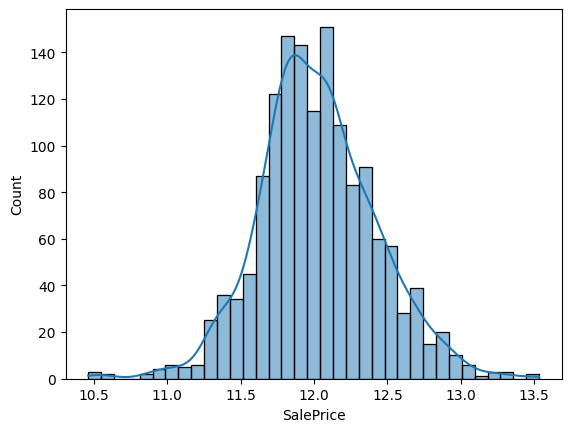

In [7]:
sns.histplot(log_target, kde=True)


<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

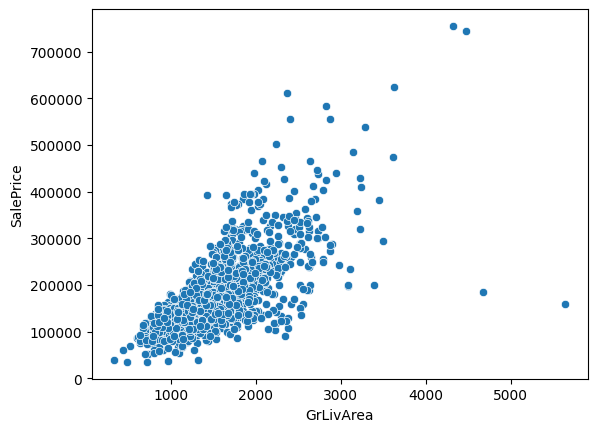

In [8]:
sns.scatterplot(data=train, x='GrLivArea', y='SalePrice')

In [11]:
missing_data = train.isnull().sum()
feature_types = train.dtypes
missing_table = pd.concat([missing_data, feature_types], axis=1)
missing_table.columns = ['Missing Count', 'Data Type']
missing_table = missing_table[missing_table['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
print(missing_table)

              Missing Count Data Type
PoolQC                 1453       str
MiscFeature            1406       str
Alley                  1369       str
Fence                  1179       str
MasVnrType              872       str
FireplaceQu             690       str
LotFrontage             259   float64
GarageType               81       str
GarageYrBlt              81   float64
GarageFinish             81       str
GarageQual               81       str
GarageCond               81       str
BsmtFinType2             38       str
BsmtExposure             38       str
BsmtFinType1             37       str
BsmtCond                 37       str
BsmtQual                 37       str
MasVnrArea                8   float64
Electrical                1       str


In [12]:
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns

In [13]:
skewed_feats = train[numeric_cols].skew().sort_values(ascending=False)
high_skew = skewed_feats[abs(skewed_feats) > 0.75]
print("Highly skewed columns that need log transformation:\n", high_skew)

Highly skewed columns that need log transformation:
 MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
dtype: float64


In [18]:

from src.preprocessing import remove_outliers, impute_structural_nan, transform_skewed_features,impute_statistical_nan
from src.engineering import engineer_features
from src.config import TARGET

train_cleaned = remove_outliers(train, is_train=True)

X_train = train_cleaned.drop(columns=[TARGET])
y_train = train_cleaned[TARGET]
y_train_log = np.log1p(y_train)

X_train = impute_structural_nan(X_train)
X_train, _ = impute_statistical_nan(X_train, X_train)

X_train = engineer_features(X_train)

X_train = transform_skewed_features(X_train)

print(f"X_train shape: {X_train.shape}")
print(f"y_train_log shape: {y_train_log.shape}")

X_train shape: (1456, 89)
y_train_log shape: (1456,)


In [ ]:
sys.path.append(os.path.abspath(os.path.join('..')))

from src.models import get_baseline_pipeline, evaluate_pipeline

# 1. Dynamically isolate column categories for the Pipeline
categorical_features = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
numerical_features = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

# 2. Initialize the baseline architecture
baseline_pipe = get_baseline_pipeline(categorical_features, numerical_features)

# 3. Run the Cross Validation loop using our log-transformed target!
mean_cv_score = evaluate_pipeline(X_train, y_train_log, baseline_pipe)

--- 5-Fold CV Results ---
Folds RMSE: [0.1183 0.1125 0.114  0.1156 0.0957]
Mean RMSE: 0.1112 (+/- 0.0080)


/var/folders/db/7m3gk53d525gp5zsx6q058hc0000gn/T/ipykernel_8230/4115061411.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
